/home/hell/.local/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


SearchResult containing 14 data products.

 #       mission      year author exptime  target_name  distance
                                     s                   arcsec 
--- ----------------- ---- ------ ------- ------------- --------
  0 Kepler Quarter 01 2009 Kepler    1800 kplr010937029      0.0
  1 Kepler Quarter 02 2009 Kepler    1800 kplr010937029      0.0
  2 Kepler Quarter 03 2009 Kepler    1800 kplr010937029      0.0
  3 Kepler Quarter 04 2010 Kepler    1800 kplr010937029      0.0
  4 Kepler Quarter 05 2010 Kepler    1800 kplr010937029      0.0
  5 Kepler Quarter 06 2010 Kepler    1800 kplr010937029      0.0
  6 Kepler Quarter 08 2011 Kepler    1800 kplr010937029      0.0
  7 Kepler Quarter 09 2011 Kepler    1800 kplr010937029      0.0
  8 Kepler Quarter 10 2011 Kepler    1800 kplr010937029      0.0
  9 Kepler Quarter 12 2012 Kepler    1800 kplr010937029      0.0
 10 Kepler Quarter 13 2012 Kepler    1800 kplr010937029      0.0
 11 Kepler Quarter 14 2012 Kepler    1800 kplr0

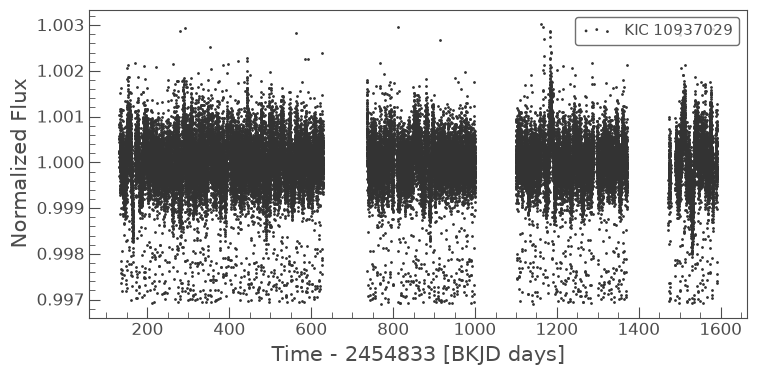

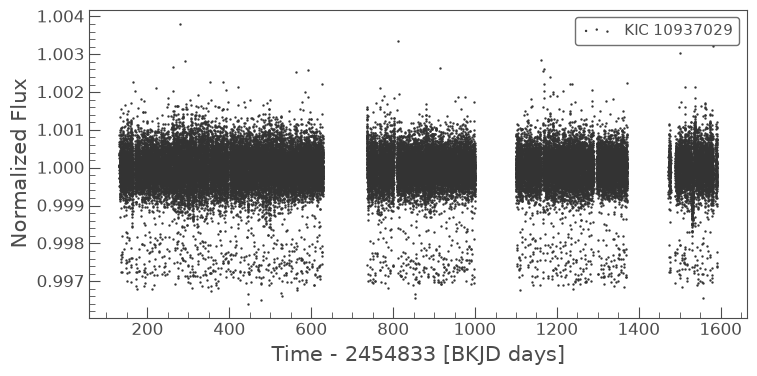

Period = 326.468647 days


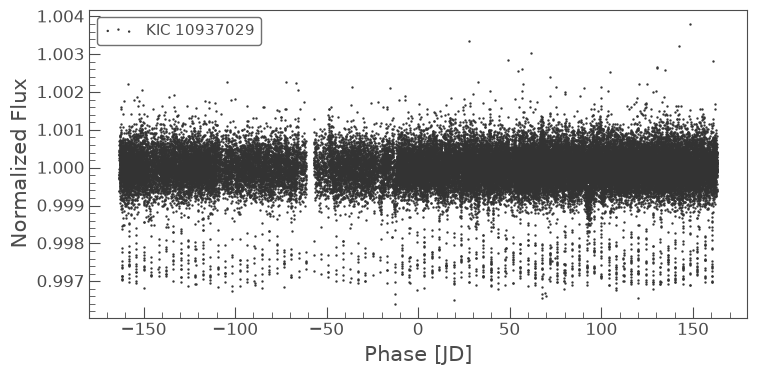

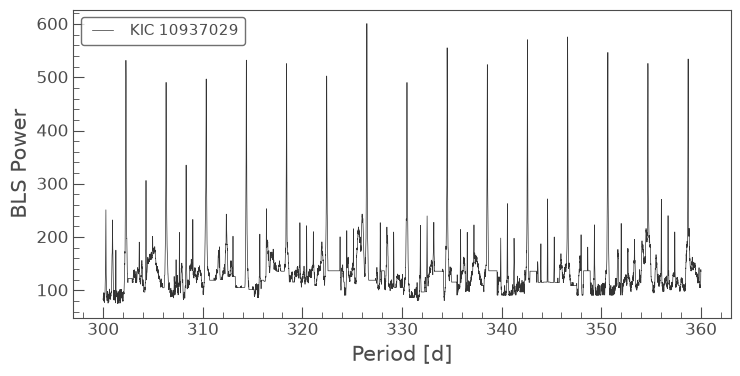

In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

search = lk.search_lightcurve("KIC 10937029", mission="Kepler", cadence="long")
print(search)

lc_collections = search.download_all()
print(lc_collections)

lc = lc_collections.stitch()

baseline = (lc.time.max() - lc.time.min()).to_value("day")

print(f"Data mulai : {lc.time.min().value:.2f} BKJD")
print(f"Data akhir : {lc.time.max().value:.2f} BKJD")
print(f"Baseline   : {baseline:.2f} hari")

# pixelfile = 
# lk.search_targetpixelfile("KIC 10937029")

# # pixelfile.animate()

# lc = pixelfile.to_lightcurve(method="pld")

lc_clean = (
    lc
    .remove_nans()
    .remove_outliers(sigma=5)
    .normalize()
)

lc_clean.scatter()

lc_flat = lc_clean.flatten(window_length=401)
lc_flat.scatter(s=2)
plt.show()

periods = np.linspace(
    300,
    360,
    10000
)

periodogram = lc_clean.to_periodogram(
    method="bls",
    period=periods
)

period = periodogram.period_at_max_power

folded = lc_flat.fold(
    period = period
)
folded.scatter(s=2)

print(f"Period = {period.value:.6f} days")

periodogram.plot()
plt.show()


# periodogram = lc_clean.to_periodogram(
#     method="bls",
#     minimum_period=200,
#     maximum_period=400
# )

# # Period of Kepler-553 c
# p_c = 328.24

# # Period of Kepler-553 b
# # p_b = 4.03
# # periodogram.plot()
# # plt.show()

# folded_lc = lc_clean.fold()
# folded_lc.scatter()
# plt.show()